#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

#### Loading the Dataset

In [2]:
df = pd.read_csv('adult.csv')

#### Data Understanding

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.shape

(48842, 15)

In [5]:
df.occupation.unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.rename(columns={'educational-num': 'educational_num', 'marital-status': 'marital_status', 'capital-gain': 'capital_gain', 'capital-loss': 'capital_loss', 'hours-per-week': 'hours_per_week', 'native-country': 'native_country'}, inplace=True)

In [9]:
df.head()

,age,workclass,fnlwgt,education,educational_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
df.income.unique()

array(['<=50K', '>50K'], dtype=object)

In [11]:
df.native_country.unique()

array(['United-States', '?', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

In [12]:
df.workclass.unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [13]:
df.marital_status.unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [14]:
df.relationship.unique()

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

In [15]:
df.occupation.unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [16]:
df.income.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

#### Data Preprocessing

In [17]:
df.replace('?', np.nan, inplace=True)

In [18]:
df.drop(columns=['fnlwgt', 'education', 'race'], inplace=True)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.income = df.income.apply(lambda x: 1 if x == '>50K' else 0)

#### Data Anaylsis

In [21]:
df.head()

,age,workclass,educational_num,marital_status,occupation,relationship,gender,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Male,7688,0,40,United-States,1
4,18,NaN,10,Never-married,NaN,Own-child,Female,0,0,30,United-States,0


In [22]:
df.groupby('occupation')['income'].agg('mean').sort_values(ascending=False)

occupation
Exec-managerial      0.468264
Prof-specialty       0.451837
Armed-Forces         0.333333
Protective-serv      0.309677
Tech-support         0.292101
Sales                0.280197
Craft-repair         0.236154
Transport-moving     0.215881
Adm-clerical         0.153531
Machine-op-inspct    0.130143
Farming-fishing      0.119832
Handlers-cleaners    0.075721
Other-service        0.047406
Priv-house-serv      0.012500
Name: income, dtype: float64

In [23]:
df.groupby('workclass')['income'].mean()

workclass
Federal-gov         0.383333
Local-gov           0.293702
Never-worked        0.000000
Private             0.225937
Self-emp-inc        0.547503
Self-emp-not-inc    0.281116
State-gov           0.270921
Without-pay         0.095238
Name: income, dtype: float64

In [24]:
df.groupby('marital_status')['income'].mean()

marital_status
Divorced                 0.108987
Married-AF-spouse        0.378378
Married-civ-spouse       0.458501
Married-spouse-absent    0.092652
Never-married            0.056240
Separated                0.065868
Widowed                  0.085007
Name: income, dtype: float64

In [25]:
df.groupby('relationship')['income'].mean()

relationship
Husband           0.463106
Not-in-family     0.112812
Other-relative    0.035616
Own-child         0.020072
Unmarried         0.064530
Wife              0.472997
Name: income, dtype: float64

In [26]:
df.groupby('native_country')['income'].mean()

native_country
Cambodia                      0.321429
Canada                        0.346154
China                         0.295082
Columbia                      0.047059
Cuba                          0.246377
Dominican-Republic            0.048544
Ecuador                       0.133333
El-Salvador                   0.070968
England                       0.370079
France                        0.421053
Germany                       0.281553
Greece                        0.367347
Guatemala                     0.034884
Haiti                         0.120000
Holand-Netherlands            0.000000
Honduras                      0.100000
Hong                          0.266667
Hungary                       0.315789
India                         0.410596
Iran                          0.372881
Ireland                       0.305556
Italy                         0.323810
Jamaica                       0.142857
Japan                         0.347826
Laos                          0.086957
Mexico    

In [27]:
print('Income rate with capital-gain > 0:', df[df['capital_gain'] > 0]['income'].mean())
print('Income rate with capital-gain = 0:', df[df['capital_gain'] == 0]['income'].mean())

Income rate with capital-gain > 0: 0.6145181476846058
Income rate with capital-gain = 0: 0.21017917701407246


In [28]:
print('Income rate with capital-loss > 0:', df[df['capital_loss'] > 0]['income'].mean())
print('Income rate with capital-loss = 0:', df[df['capital_loss'] == 0]['income'].mean())

Income rate with capital-loss > 0: 0.49845338046840476
Income rate with capital-loss = 0: 0.23475664225007017


#### Features Engineering

In [29]:
def simplify_marital(status):
    if status == 'Married-civ-spouse' or status == 'Married-AF-spouse':
        return 'Married'
    elif status == 'Never-married':
        return 'Single'
    else:
        return 'Previously-Married'  # Divorced, Widowed

df['marital_status'] = df['marital_status'].apply(simplify_marital)

In [32]:
df['capital_total'] = df['capital_gain'] - df['capital_loss']
# droping the capital gain and loss and adding the net capital column
df.drop(['capital_gain', 'capital_loss'], axis=1, inplace=True)

#### Spliting Features and Target

In [33]:
X = df.drop('income', axis=1)
y = df.income

#### Spliting the Training and Testing Data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=21, stratify=y)

#### Pipelines

In [35]:
cat_cols = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing_value')),
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [36]:
num_cols = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

In [37]:
preprocessor = ColumnTransformer([
    ('num', num_cols, make_column_selector(dtype_include=np.number)),
    ('cat', cat_cols, make_column_selector(dtype_include=object))
])

#### Model Evaluation function

In [38]:
results = []

def evaluate_model(model_name, model):
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=24)),
        ('model', model)
    ])

    model_pipeline.fit(X_train, y_train)
    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)

    train_accuracy  = accuracy_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_f1_score = f1_score(y_train, y_pred_train)
    
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_f1_score = f1_score(y_test, y_pred_test)

    print(f'-----------------------------------')
    print(f'   Model: {model_name}')
    print(f'------------------------------------')
    print('--------- Training Data ----------')
    print(f'Train Accuracy:    {round(train_accuracy*100, 2)}%')
    print(f'Train Precision:   {round(train_precision*100, 2)}%')
    print(f'Train Recall:      {round(train_recall*100, 2)}%')
    print(f'Train F1 Score:    {round(train_f1_score*100, 2)}%')
    print()
    print('--------- Testing Data -----------')
    print(f'Test Accuracy:   {round(test_accuracy*100, 2)}%')
    print(f'Test Precision:  {round(test_precision*100, 2)}%')
    print(f'Test Recall:    {round(test_recall*100, 2)}%')
    print(f'Test F1 Score:  {round(test_f1_score*100, 2)}%')
    print()
    print('Classification Report (Test):')
    print(classification_report(y_test, y_pred_test))
    print()

    results.append({
        'Model': model_name,
        'Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1-Score': test_f1_score
    })
    
    return model_pipeline

In [39]:
logistic_regression = evaluate_model('Logistic Regression', LogisticRegression())

-----------------------------------
   Model: Logistic Regression
------------------------------------
--------- Training Data ----------
Train Accuracy:    79.99%
Train Precision:   56.65%
Train Recall:      83.82%
Train F1 Score:    67.6%

--------- Testing Data -----------
Test Accuracy:   79.44%
Test Precision:  56.03%
Test Recall:    81.33%
Test F1 Score:  66.35%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      7779
           1       0.56      0.81      0.66      2582

    accuracy                           0.79     10361
   macro avg       0.74      0.80      0.76     10361
weighted avg       0.84      0.79      0.81     10361




In [40]:
decision_tree = evaluate_model('Decision Tree', DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=21))

-----------------------------------
   Model: Decision Tree
------------------------------------
--------- Training Data ----------
Train Accuracy:    82.55%
Train Precision:   60.89%
Train Recall:      83.78%
Train F1 Score:    70.52%

--------- Testing Data -----------
Test Accuracy:   81.03%
Test Precision:  58.79%
Test Recall:    79.9%
Test F1 Score:  67.74%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.81      0.87      7779
           1       0.59      0.80      0.68      2582

    accuracy                           0.81     10361
   macro avg       0.76      0.81      0.77     10361
weighted avg       0.84      0.81      0.82     10361




In [41]:
svm = evaluate_model('SVM', SVC(kernel='rbf', C=1.0))

-----------------------------------
   Model: SVM
------------------------------------
--------- Training Data ----------
Train Accuracy:    81.41%
Train Precision:   58.48%
Train Recall:      87.56%
Train F1 Score:    70.13%

--------- Testing Data -----------
Test Accuracy:   80.1%
Test Precision:  56.8%
Test Recall:    84.12%
Test F1 Score:  67.81%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      7779
           1       0.57      0.84      0.68      2582

    accuracy                           0.80     10361
   macro avg       0.75      0.81      0.77     10361
weighted avg       0.85      0.80      0.81     10361




In [42]:
knn = evaluate_model('K-NN', KNeighborsClassifier(n_neighbors=5))

-----------------------------------
   Model: K-NN
------------------------------------
--------- Training Data ----------
Train Accuracy:    86.05%
Train Precision:   65.58%
Train Recall:      92.64%
Train F1 Score:    76.79%

--------- Testing Data -----------
Test Accuracy:   78.07%
Test Precision:  54.29%
Test Recall:    76.03%
Test F1 Score:  63.34%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      7779
           1       0.54      0.76      0.63      2582

    accuracy                           0.78     10361
   macro avg       0.73      0.77      0.74     10361
weighted avg       0.82      0.78      0.79     10361




#### Model Comparision

In [43]:
results_df = pd.DataFrame(results)

In [44]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.794421,0.560299,0.813323,0.663507
1,Decision Tree,0.810346,0.587917,0.798993,0.677393
2,SVM,0.800984,0.567992,0.841208,0.678114
3,K-NN,0.780716,0.542865,0.760263,0.633430


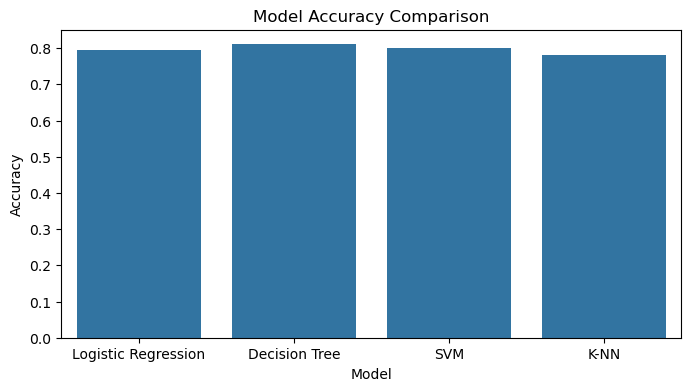

In [45]:
plt.figure(figsize=(8,4))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.xticks(rotation=0)
plt.title('Model Accuracy Comparison')
plt.show()

##### Saving the Model to pickle file 

In [46]:
import pickle as pkl

In [47]:
with open('model.pkl', 'wb') as file:
    pkl.dump(decision_tree, file)

print('Model Saved!')

Model Saved!
